# Telecom Customer Churn Prediction
> End-to-end pipeline: environment setup → EDA → modelling → MLflow tracking → deployment artifacts

**Sections**
1. Environment & Secrets
2. Package Installation
3. Data Ingestion
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Model Building & Evaluation
7. Hyperparameter Optimisation (RandomizedSearchCV + Optuna)
8. MLflow Experiment Tracking
9. Model Persistence
10. MongoDB Integration
11. Deployment Artifacts (Streamlit app)

## 1  Environment & Secrets
All secrets are read from **Colab Secrets** — set them in the 🔑 Secrets panel before running.

In [4]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ─────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ─────────────────────────────────────────────────────────
USE_DAGSHUB = True  # Set False to log locally inside Colab

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — experiment logs saved inside Colab filesystem
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 2  Package Installation

In [5]:
!pip install -q \
    pandas numpy matplotlib seaborn \
    scikit-learn imbalanced-learn \
    xgboost lightgbm catboost optuna \
    mlflow dagshub pymongo joblib streamlit

print('✅ Packages installed.')

✅ Packages installed.


## 3  Data Ingestion
Upload `Customer-Churn.csv` when prompted.

In [3]:
from google.colab import files
import io, pandas as pd

# Upload CSV file when prompted
uploaded = files.upload()
filename = list(uploaded.keys())[0]
raw_df   = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Loaded  →  {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
raw_df.head()

Saving Customer-Churn.csv to Customer-Churn (1).csv
Loaded  →  7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4  Exploratory Data Analysis (EDA)

### 4.1  Basic Overview

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

print('Shape:', raw_df.shape)
print('Columns:', raw_df.columns.tolist())
print('\nData types:')
print(raw_df.dtypes)
print('\nDescriptive statistics:')
raw_df.describe()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Descriptive statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 4.2  Target Variable Distribution

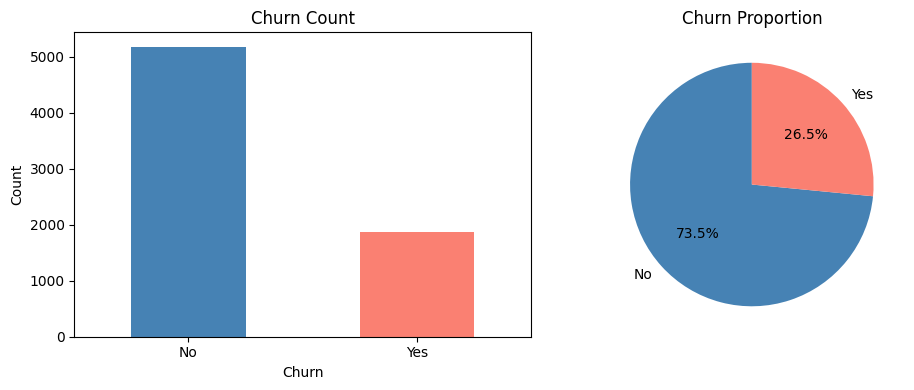

Churn rate (%):
Churn
No     73.46
Yes    26.54
Name: count, dtype: float64


In [7]:
churn_counts = raw_df['Churn'].value_counts()
churn_pct    = churn_counts / len(raw_df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue','salmon'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print('Churn rate (%):')
print(churn_pct.round(2))

### 4.3  Missing Value Analysis

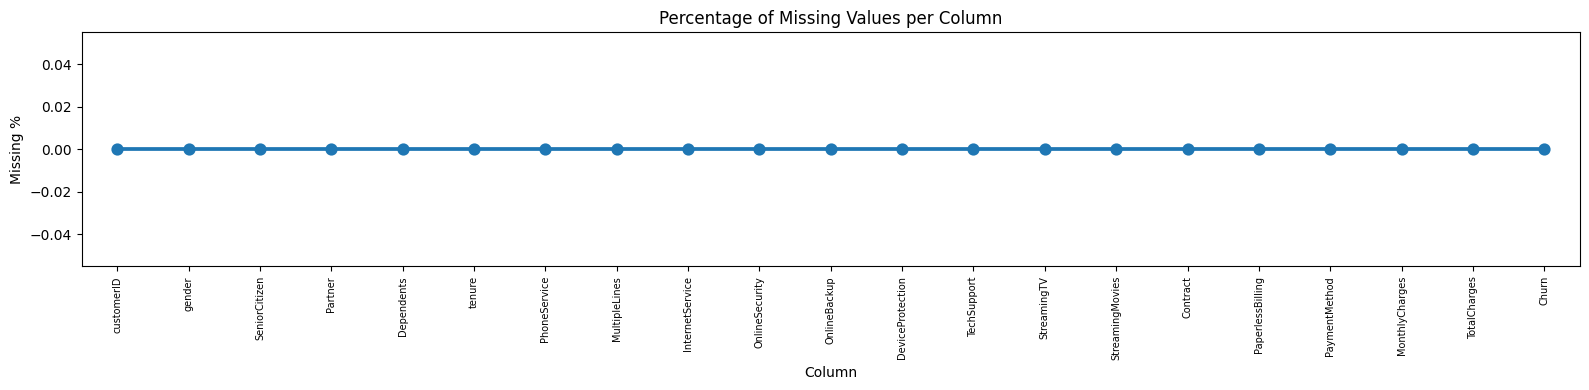

Null counts per column:
Series([], dtype: int64)


In [8]:
missing = (raw_df.isnull().sum() * 100 / raw_df.shape[0]).reset_index()
missing.columns = ['Column', 'Missing_%']

plt.figure(figsize=(16, 4))
sns.pointplot(x='Column', y='Missing_%', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing %')
plt.tight_layout()
plt.show()

print('Null counts per column:')
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])

### 4.4  Univariate Analysis — Categorical Features vs Churn

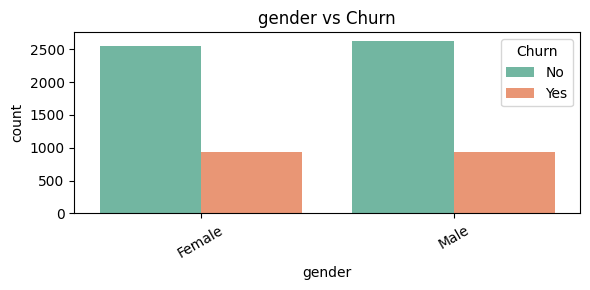

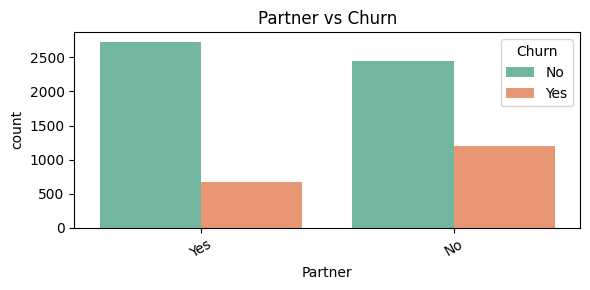

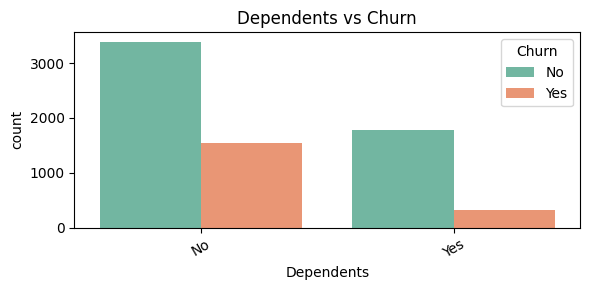

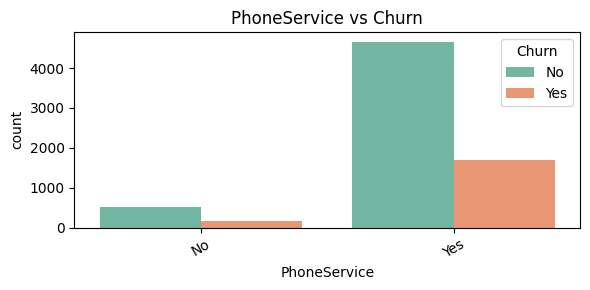

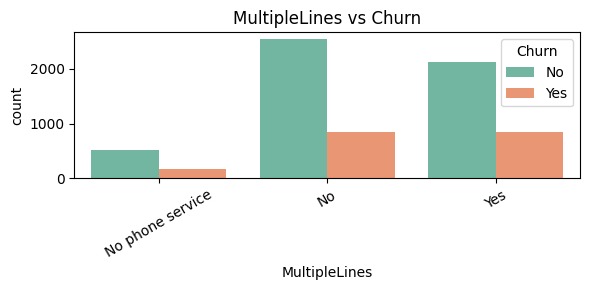

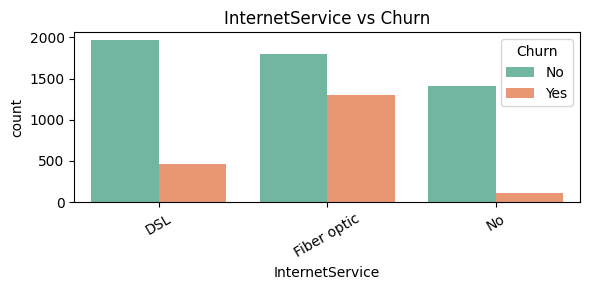

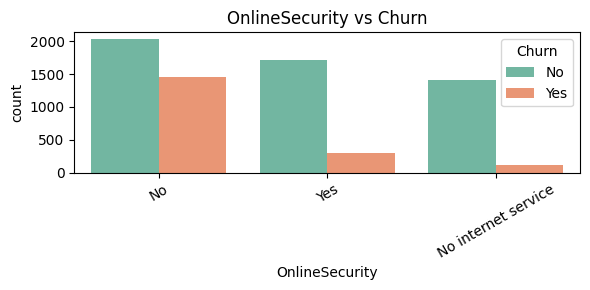

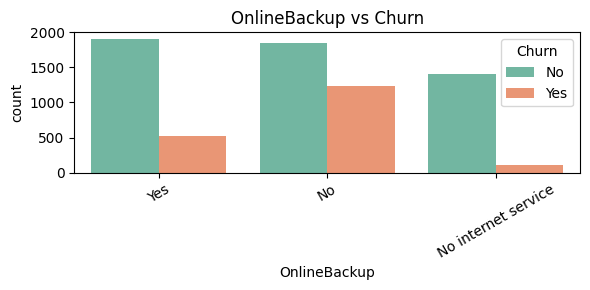

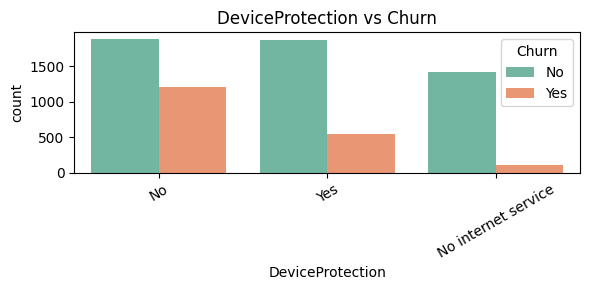

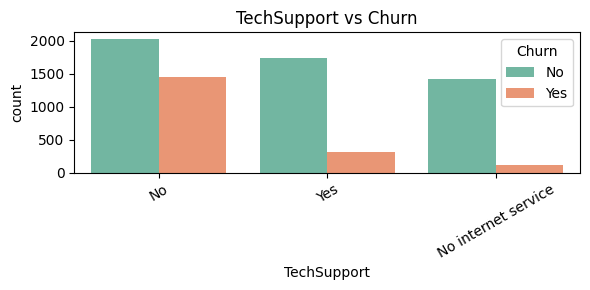

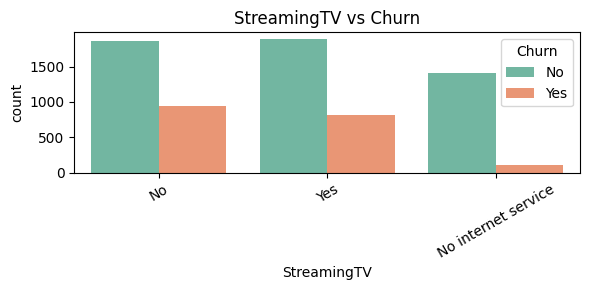

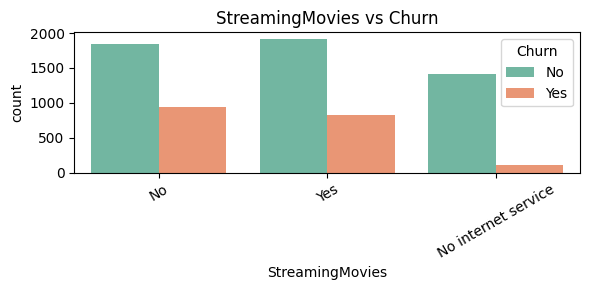

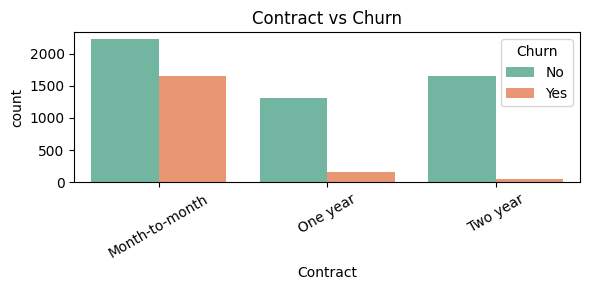

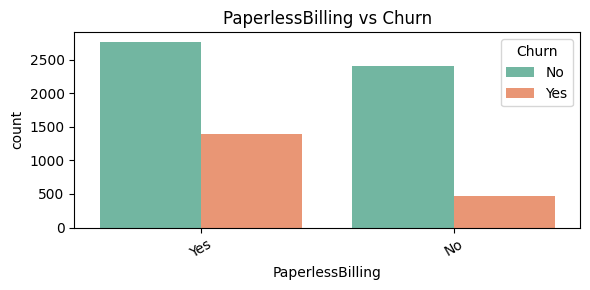

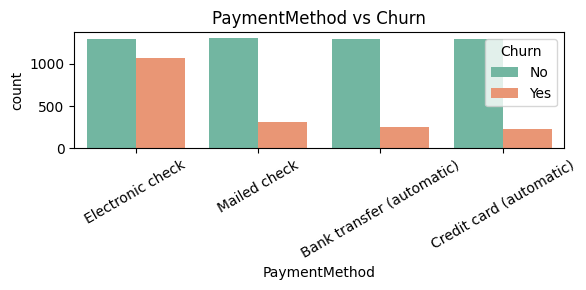

In [9]:
def plot_categorical_churn(df, cols, hue='Churn'):
    """Bar count plots for each categorical feature split by Churn label."""
    for col in cols:
        plt.figure(figsize=(6, 3))
        sns.countplot(data=df, x=col, hue=hue, palette='Set2')
        plt.title(f'{col} vs {hue}')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

# Categorical columns excluding ID and target
cat_cols = [c for c in raw_df.select_dtypes('object').columns
            if c not in ('customerID', 'Churn', 'TotalCharges')]

plot_categorical_churn(raw_df, cat_cols)

### 4.5  Bivariate Analysis — Styled Count Plots

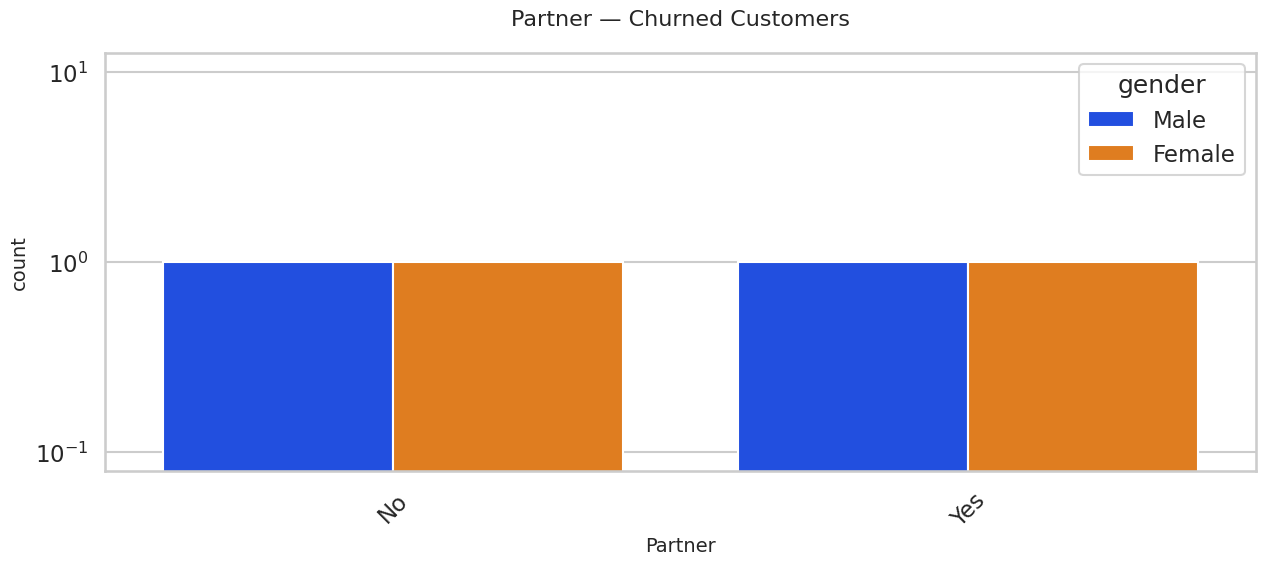

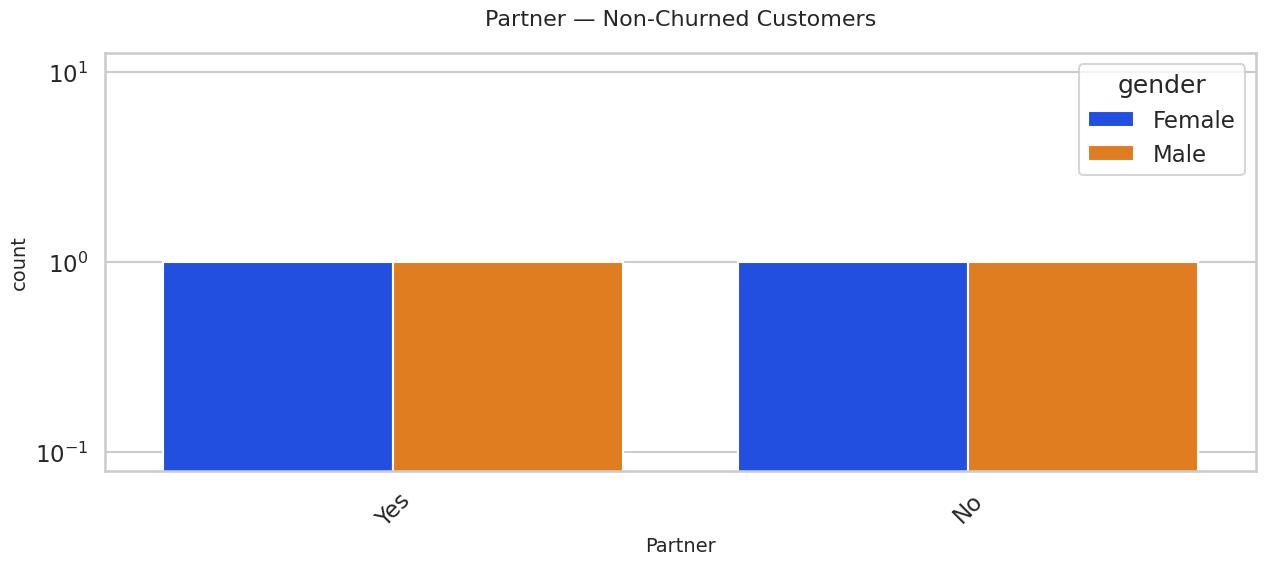

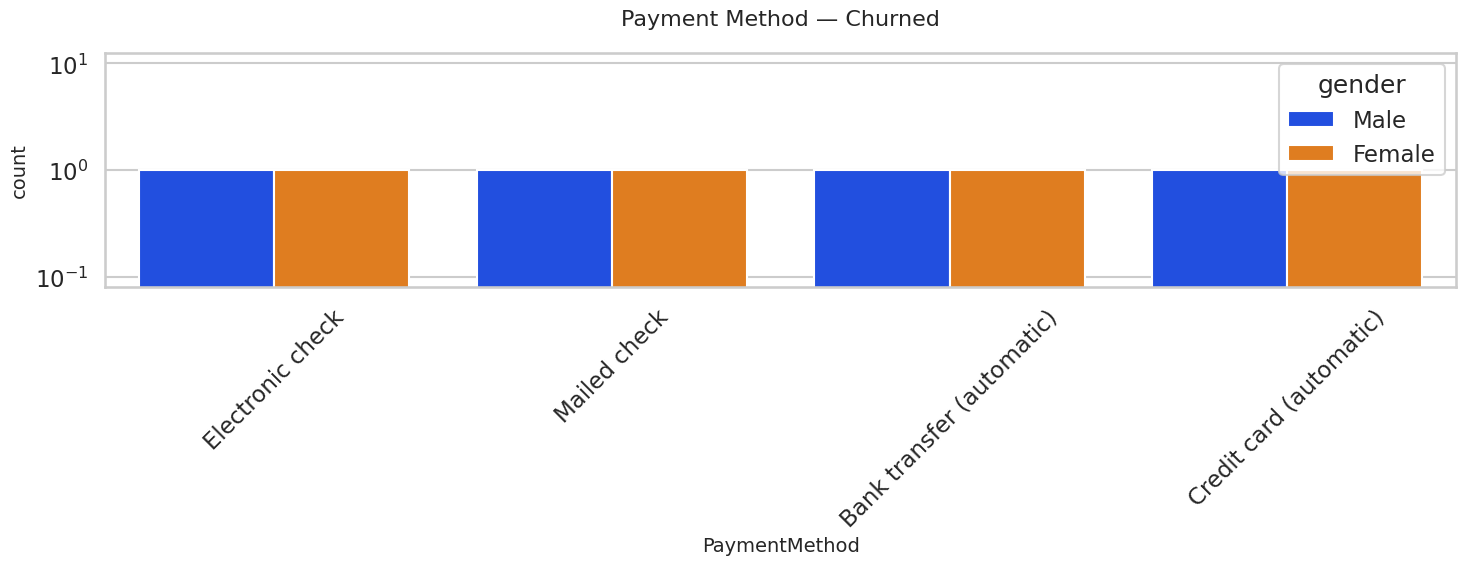

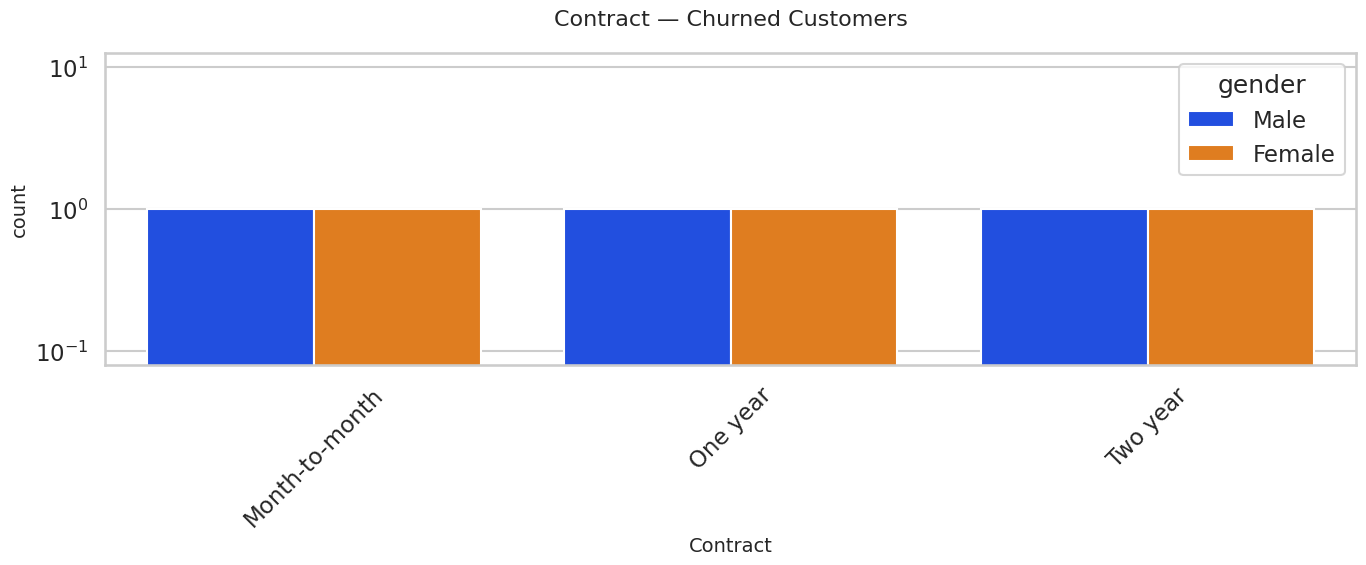

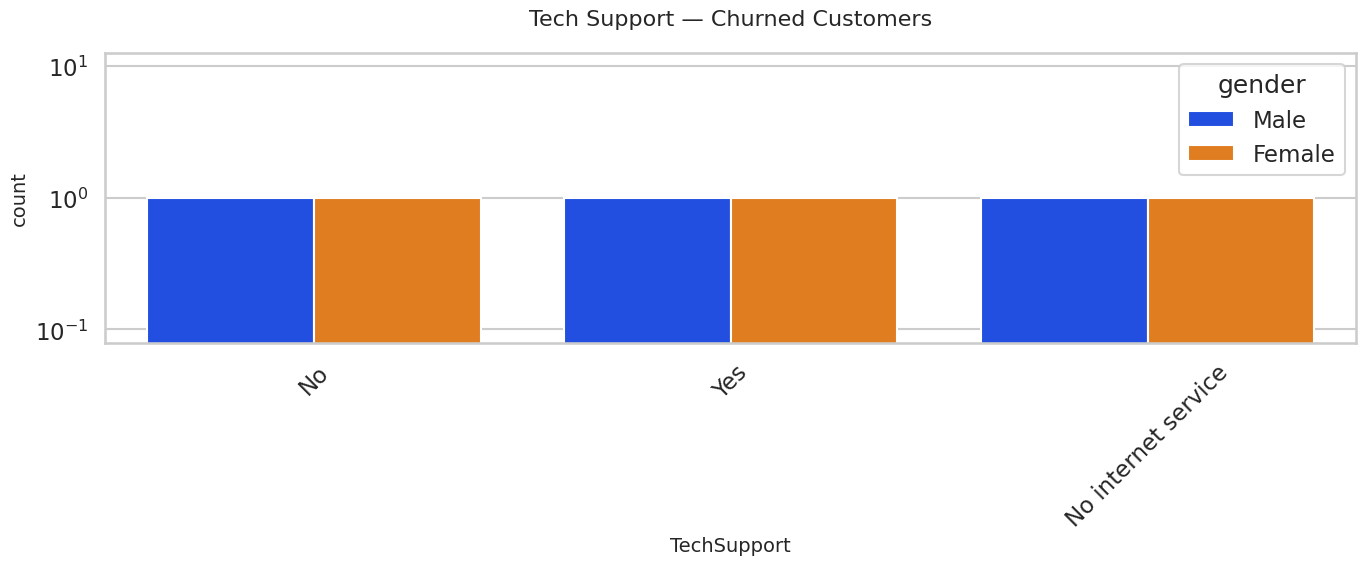

In [10]:
def uniplot(df, col, title, hue=None):
    """Log-scale count plot for detailed bivariate exploration."""
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['axes.titlepad']  = 20

    temp  = pd.Series(data=hue)
    width = len(df[col].unique()) + 7 + 4 * len(temp.unique())
    fig, ax = plt.subplots(figsize=(max(width, 8), 6))
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.title(title)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index,
                  hue=hue, palette='bright', ax=ax)
    plt.tight_layout()
    plt.show()

churned     = raw_df[raw_df['Churn'] == 'Yes']
not_churned = raw_df[raw_df['Churn'] == 'No']

uniplot(churned,     'Partner',       'Partner — Churned Customers',      hue='gender')
uniplot(not_churned, 'Partner',       'Partner — Non-Churned Customers',  hue='gender')
uniplot(churned,     'PaymentMethod', 'Payment Method — Churned',         hue='gender')
uniplot(churned,     'Contract',      'Contract — Churned Customers',      hue='gender')
uniplot(churned,     'TechSupport',   'Tech Support — Churned Customers',  hue='gender')

### 4.6  Charge Distribution by Churn

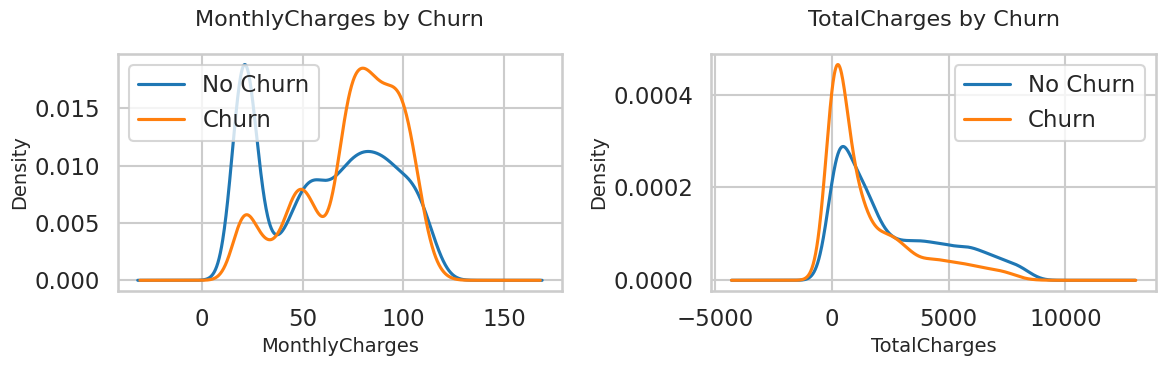

In [11]:
# Convert TotalCharges to numeric for EDA (original raw_df unchanged)
eda_df = raw_df.copy()
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')
eda_df['Churn_bin']    = (eda_df['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges']):
    for label, grp in eda_df.groupby('Churn_bin'):
        grp[col].dropna().plot.kde(ax=ax, label='Churn' if label else 'No Churn')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

### 4.7  Monthly vs Total Charges Scatter & Correlation

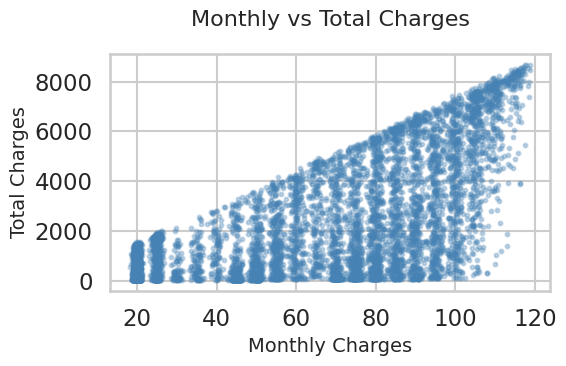

Pearson correlation (MonthlyCharges vs TotalCharges): 0.6511


In [12]:
# Scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(eda_df['MonthlyCharges'], eda_df['TotalCharges'],
            alpha=0.3, s=8, color='steelblue')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.title('Monthly vs Total Charges')
plt.tight_layout()
plt.show()

corr = eda_df['MonthlyCharges'].corr(eda_df['TotalCharges'])
print(f'Pearson correlation (MonthlyCharges vs TotalCharges): {corr:.4f}')

### 4.8  Correlation Heatmap

/tmp/ipykernel_16065/3079050834.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


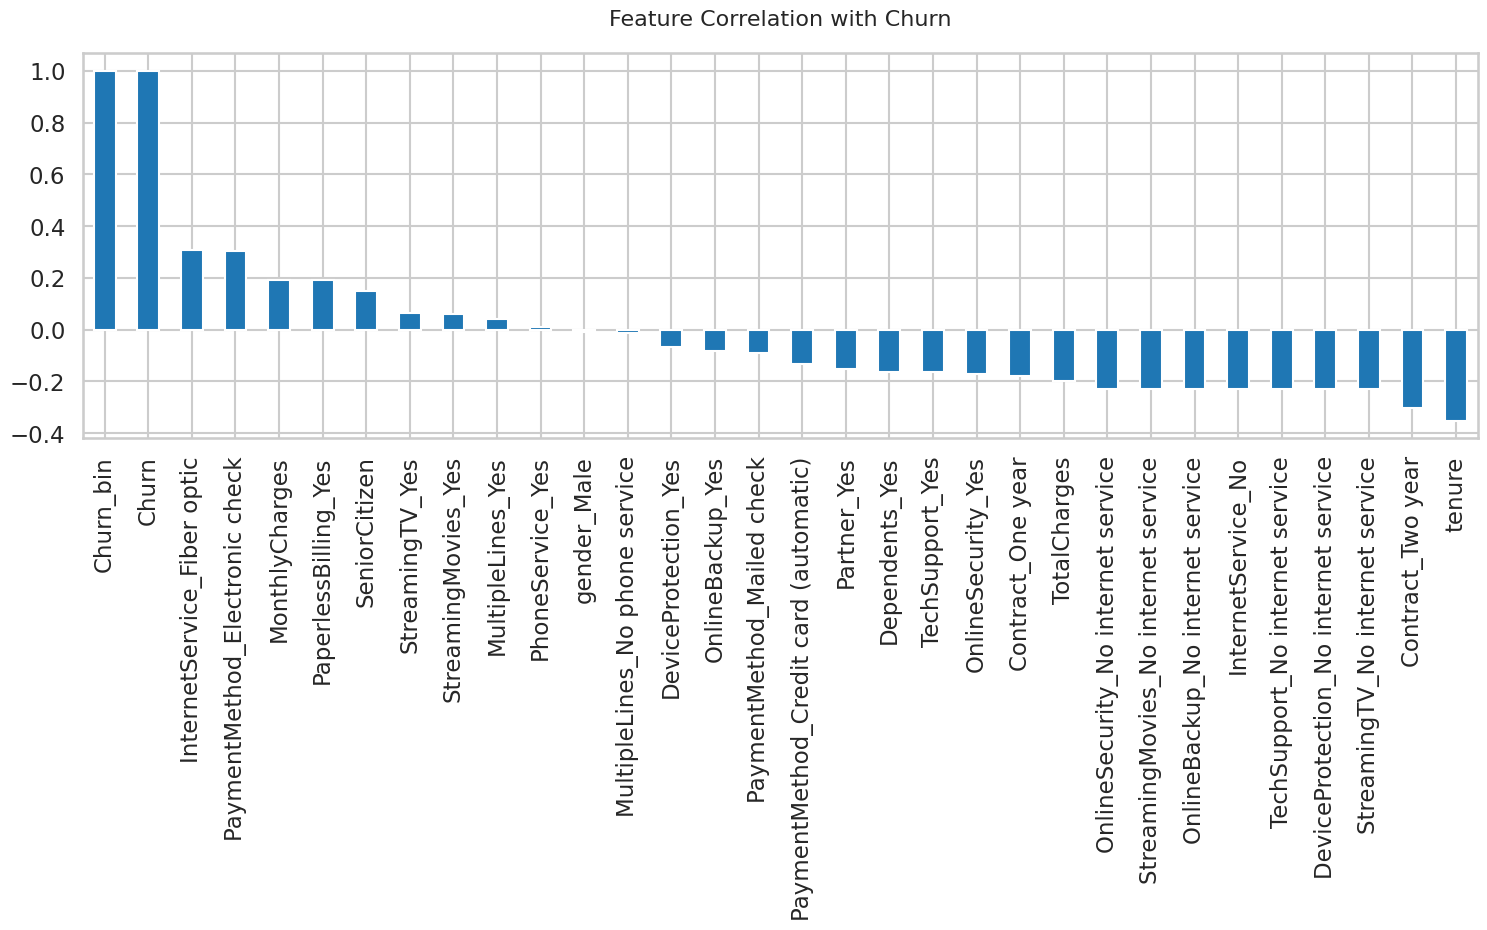

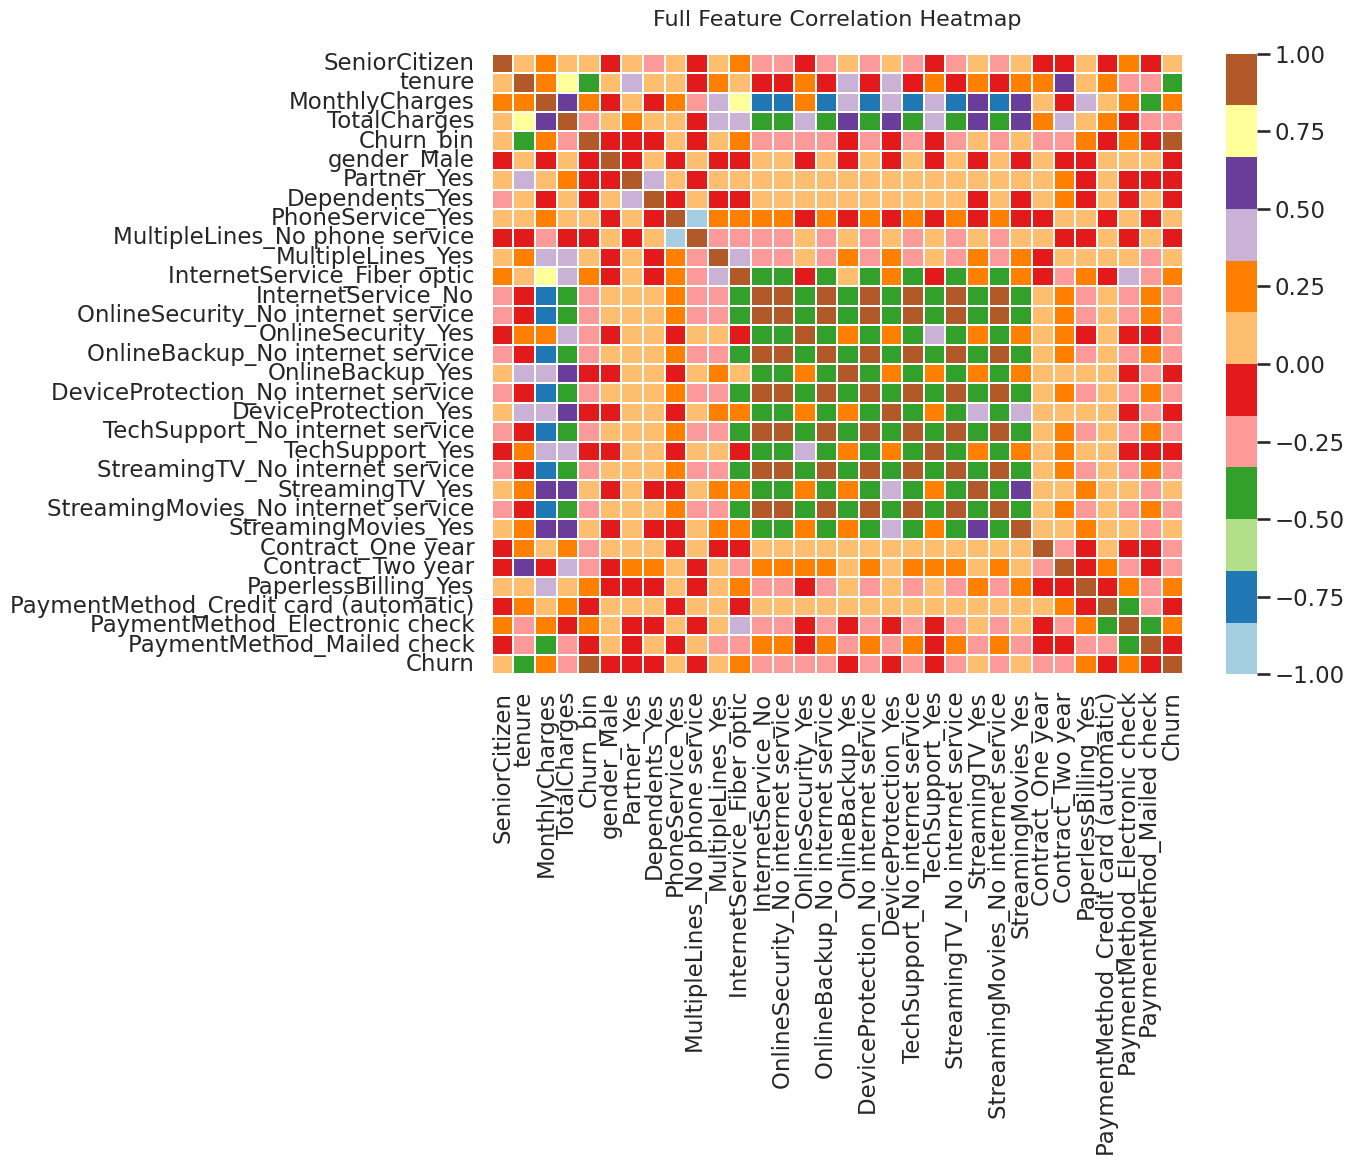

In [13]:
# One-hot encode EDA copy for numeric correlation
eda_dummies = pd.get_dummies(
    eda_df.drop(columns=['customerID', 'Churn']), drop_first=True
)
eda_dummies['Churn'] = eda_df['Churn_bin']

# Bar chart: per-feature correlation with Churn
plt.figure(figsize=(18, 5))
eda_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Correlation with Churn')
plt.tight_layout()
plt.show()

# Full heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(eda_dummies.corr(), cmap='Paired', linewidths=0.3)
plt.title('Full Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### 4.9  EDA Key Insights
| Insight | Detail |
|---------|--------|
| Imbalanced dataset | ~73% No-Churn vs 27% Churn |
| Month-to-month contracts | Churn rate ~41% |
| No Online Security / No Tech Support | High churn groups |
| Electronic check payment | Highest churn rate (~44%) |
| Tenure 1–12 months | Very high churn |
| Higher Monthly + Lower Total Charges | Linked to churn |
| Gender / PhoneService | Almost no impact on churn |

## 5  Data Preprocessing

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter

# ── 5.1  Clean raw data ───────────────────────────────────────────────────────
telco = raw_df.copy()

# TotalCharges is stored as a string — convert to float
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

# 11 rows have NaN TotalCharges (0.15% of data) — safe to drop
telco.dropna(how='any', inplace=True)
print(f'After cleaning: {telco.shape[0]:,} rows')

# ── 5.2  Tenure binning (1-year intervals) ────────────────────────────────────
bins   = [0, 12, 24, 36, 48, 60, 72]
labels = ['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']
telco['tenure_bin'] = pd.cut(telco['tenure'], bins=bins,
                             labels=labels, include_lowest=True)
print('Tenure group distribution:')
print(telco['tenure_bin'].value_counts().sort_index())

# ── 5.3  Feature / target split ───────────────────────────────────────────────
# Drop raw tenure (replaced by tenure_bin), customerID (non-informative), and target
X = telco.drop(columns=['customerID', 'Churn', 'tenure'])
y = telco['Churn'].map({'No': 0, 'Yes': 1})

# One-hot encode all remaining categoricals; drop_first avoids multicollinearity
X = pd.get_dummies(X, drop_first=True)

print(f'\nFeature matrix: {X.shape}')
print(f'Target vector:  {y.shape}')
print(f'Class balance:  {Counter(y)}')

# ── 5.4  Stratified train / test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

# ── 5.5  StandardScaler (fit on train, transform both splits) ────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Preprocessing complete.')

After cleaning: 7,032 rows
Tenure group distribution:
tenure_bin
1-12     2175
13-24    1024
25-36     832
37-48     762
49-60     832
61-72    1407
Name: count, dtype: int64

Feature matrix: (7032, 34)
Target vector:  (7032,)
Class balance:  Counter({0: 5163, 1: 1869})

Train: (5625, 34)  |  Test: (1407, 34)
Preprocessing complete.


## 6  Model Building & Evaluation

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, sample_weight=None):
    """Fit a model, print classification report, and display confusion matrix."""
    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)

    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_te, y_pred))

    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return model, y_pred

### 6.1  Baseline — Decision Tree

  Decision Tree (Baseline)
Accuracy: 0.7107
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.46      0.49      0.47       374

    accuracy                           0.71      1407
   macro avg       0.63      0.64      0.64      1407
weighted avg       0.72      0.71      0.71      1407



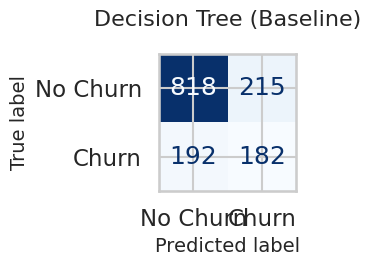

In [16]:
model_dt_base, _ = evaluate_model(
    'Decision Tree (Baseline)',
    DecisionTreeClassifier(random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

### 6.2  SMOTEENN — Combined Over + Under Sampling

Class distribution after SMOTEENN: Counter({1: 2987, 0: 2205})
  Decision Tree + SMOTEENN
Accuracy: 0.7249
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407



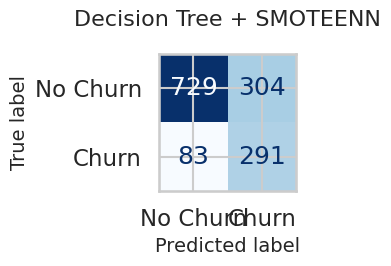

  Random Forest (n=500) + SMOTEENN
Accuracy: 0.7299
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.70      1407
weighted avg       0.80      0.73      0.75      1407



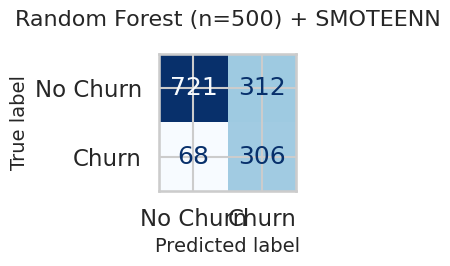

In [17]:
from imblearn.combine import SMOTEENN

# SMOTEENN = SMOTE oversampling + Edited Nearest Neighbours cleaning
sm = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = sm.fit_resample(X_train_sc, y_train)
print('Class distribution after SMOTEENN:', Counter(y_train_smoteenn))

model_dt_sm, _ = evaluate_model(
    'Decision Tree + SMOTEENN',
    DecisionTreeClassifier(random_state=42),
    X_train_smoteenn, y_train_smoteenn, X_test_sc, y_test
)

model_rf_sm, _ = evaluate_model(
    'Random Forest (n=500) + SMOTEENN',
    RandomForestClassifier(n_estimators=500, random_state=42),
    X_train_smoteenn, y_train_smoteenn, X_test_sc, y_test
)

### 6.3  XGBoost Variants

scale_pos_weight = 2.76
  XGBoost (scale_pos_weight)
Accuracy: 0.7463
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.75      0.76      1407



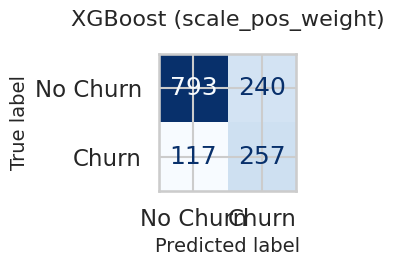

In [18]:
from xgboost import XGBClassifier

# Class-imbalance ratio for scale_pos_weight
neg_count        = (y_train == 0).sum()
pos_count        = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

# XGBoost with built-in class weighting
model_xgb_w, _ = evaluate_model(
    'XGBoost (scale_pos_weight)',
    XGBClassifier(scale_pos_weight=scale_pos_weight,
                  random_state=42, eval_metric='logloss'),
    X_train_sc, y_train, X_test_sc, y_test
)

After SMOTE: Counter({0: 4130, 1: 4130})
  XGBoost + SMOTE
Accuracy: 0.7697
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.57      0.58      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



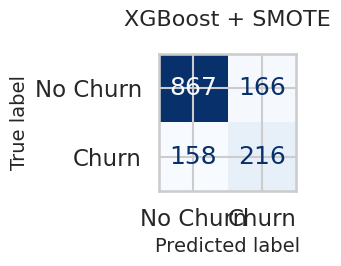

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)
print('After SMOTE:', Counter(y_train_smote))

model_xgb_smote, _ = evaluate_model(
    'XGBoost + SMOTE',
    XGBClassifier(random_state=42, eval_metric='logloss'),
    X_train_smote, y_train_smote, X_test_sc, y_test
)

### 6.4  AdaBoost with Sample Weights

  AdaBoost (sample weights)
Accuracy: 0.7321
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407



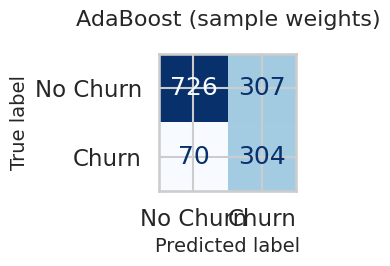

In [20]:
# Assign higher weight to minority (churn=1) class samples
sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

model_ada, y_pred_ada = evaluate_model(
    'AdaBoost (sample weights)',
    AdaBoostClassifier(n_estimators=50, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test,
    sample_weight=sample_weight
)

### 6.5  CatBoost & LightGBM

  Random Forest (class_weight=balanced)
Accuracy: 0.7193
              precision    recall  f1-score   support

           0       0.90      0.70      0.78      1033
           1       0.48      0.78      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



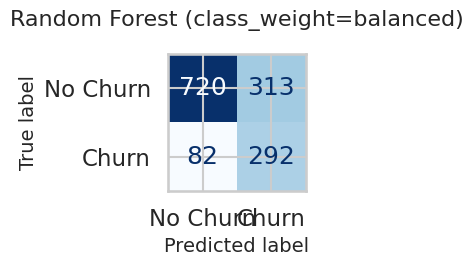

  CatBoost (auto_class_weights=Balanced)
Accuracy: 0.7434
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



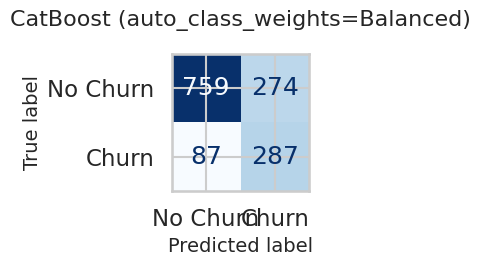

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002687 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 606
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
  LightGBM (scale_pos_weight)
Accuracy: 0.7491
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1033
           1       0.52      0.75      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


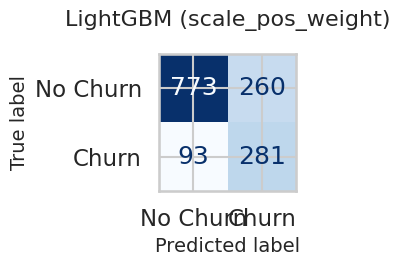

In [21]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Balanced Random Forest
model_rf_bal, _ = evaluate_model(
    'Random Forest (class_weight=balanced)',
    RandomForestClassifier(class_weight='balanced', n_estimators=300,
                           max_depth=6, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

# CatBoost with automatic class-weight balancing
model_cat, _ = evaluate_model(
    'CatBoost (auto_class_weights=Balanced)',
    CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

# LightGBM
model_lgb, _ = evaluate_model(
    'LightGBM (scale_pos_weight)',
    LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

## 7  Hyperparameter Optimisation

### 7.1  RandomizedSearchCV — XGBoost

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     [100, 200, 300, 400],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'scale_pos_weight': [1, scale_pos_weight],
}

rscv = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, n_iter=50, cv=5,
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
rscv.fit(X_train_sc, y_train)

print('Best parameters:', rscv.best_params_)
print('Best CV F1:     ', round(rscv.best_score_, 4))

best_xgb_rscv = rscv.best_estimator_
y_pred_rscv   = best_xgb_rscv.predict(X_test_sc)
print('\nTest Classification Report:')
print(classification_report(y_test, y_pred_rscv))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': 0.8, 'scale_pos_weight': np.float64(2.762541806020067), 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV F1:      0.6353

Test Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



### 7.2  Optuna Fine-tuning — XGBoost

In [23]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer
optuna.logging.set_verbosity(optuna.logging.WARNING)

f1_scorer = make_scorer(f1_score, average='binary', pos_label=1)


def objective(trial):
    """Maximise cross-validated F1 on the minority (churn) class."""
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight': trial.suggest_categorical(
                                'scale_pos_weight', [1, scale_pos_weight]),
        'random_state': 42,
        'eval_metric': 'logloss',
    }
    model = XGBClassifier(**params)
    return cross_val_score(
        model, X_train_sc, y_train, cv=5,
        scoring=f1_scorer, n_jobs=-1
    ).mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print('Best Optuna params:', study.best_params)
print('Best CV F1:        ', round(study.best_value, 4))

best_xgb_optuna = XGBClassifier(**study.best_params)
best_xgb_optuna.fit(X_train_sc, y_train)
y_pred_optuna = best_xgb_optuna.predict(X_test_sc)
print('\nTest Classification Report:')
print(classification_report(y_test, y_pred_optuna))

  0%|          | 0/100 [00:00<?, ?it/s]

Best Optuna params: {'max_depth': 6, 'learning_rate': 0.013006122498333581, 'n_estimators': 267, 'subsample': 0.8610699599684971, 'colsample_bytree': 0.6662552925289141, 'min_child_weight': 9, 'gamma': 0.47447226705422796, 'reg_alpha': 0.7092609021346579, 'reg_lambda': 0.19650343795903447, 'scale_pos_weight': np.float64(2.762541806020067)}
Best CV F1:         0.6392

Test Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



## 8  MLflow Experiment Tracking
All runs are logged to the URI set in Section 1 (DagsHub or local `mlruns/`).

In [24]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.metrics import f1_score, precision_score, recall_score

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('telecom_churn_prediction')


def log_run(run_name, model, y_pred):
    """Log parameters, metrics and model artefact for a single experiment run."""
    with mlflow.start_run(run_name=run_name):
        # Log model hyper-parameters
        if hasattr(model, 'get_params'):
            mlflow.log_params(model.get_params())

        # Compute classification metrics
        mlflow.log_metric('accuracy',  round(accuracy_score(y_test, y_pred), 4))
        mlflow.log_metric('f1_score',  round(f1_score(y_test, y_pred), 4))
        mlflow.log_metric('precision', round(precision_score(y_test, y_pred), 4))
        mlflow.log_metric('recall',    round(recall_score(y_test, y_pred), 4))

        # Log the model artefact with appropriate flavour
        if isinstance(model, XGBClassifier):
            mlflow.xgboost.log_model(model, 'model')
        else:
            mlflow.sklearn.log_model(model, 'model')

        print(f'Logged run: {run_name}')


log_run('AdaBoost_weighted',     model_ada,       y_pred_ada)
log_run('XGB_scale_pos_weight',  model_xgb_w,     model_xgb_w.predict(X_test_sc))
log_run('XGB_RandomizedSearch',  best_xgb_rscv,   y_pred_rscv)
log_run('XGB_Optuna',            best_xgb_optuna, y_pred_optuna)
print('All runs logged to MLflow.')

2026/04/28 03:40:52 INFO mlflow.tracking.fluent: Experiment with name 'telecom_churn_prediction' does not exist. Creating a new experiment.
2026/04/28 03:40:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 03:40:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: AdaBoost_weighted
🏃 View run AdaBoost_weighted at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15/runs/d60f033eca7940d9bb22dbecf4d931c0
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15


2026/04/28 03:41:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged run: XGB_scale_pos_weight
🏃 View run XGB_scale_pos_weight at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15/runs/25cdae7063c840fbb45bb81a6800442a
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15


2026/04/28 03:41:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged run: XGB_RandomizedSearch
🏃 View run XGB_RandomizedSearch at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15/runs/62b45ac68e14468ebc1981349daa9536
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15


2026/04/28 03:42:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged run: XGB_Optuna
🏃 View run XGB_Optuna at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15/runs/a9e21a4b6fe949a48e596dd89ec3d7d5
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/15
All runs logged to MLflow.


## 9  Model Persistence
Save all models and preprocessing artefacts to disk.

In [25]:
import joblib, json as _json

# AdaBoost — baseline production model shipped with the project
joblib.dump(model_ada,       'ada_boost_churn_model.pkl')

# Best XGBoost from RandomizedSearchCV
joblib.dump(best_xgb_rscv,   'best_xgboost_churn_model.pkl')

# Best XGBoost from Optuna
joblib.dump(best_xgb_optuna, 'best_optuna_churn_model.pkl')

# StandardScaler — needed for inference to match training feature scaling
joblib.dump(scaler,          'standard_scaler.pkl')

# Feature columns — ensures inference uses identical column order
with open('feature_columns.json', 'w') as f:
    _json.dump(list(X.columns), f)

print('Saved artefacts:')
for fname in ['ada_boost_churn_model.pkl', 'best_xgboost_churn_model.pkl',
              'best_optuna_churn_model.pkl', 'standard_scaler.pkl',
              'feature_columns.json']:
    import os as _os
    size = _os.path.getsize(fname)
    print(f'  {fname:40s}  {size:>8,} bytes')

Saved artefacts:
  ada_boost_churn_model.pkl                   33,444 bytes
  best_xgboost_churn_model.pkl               656,518 bytes
  best_optuna_churn_model.pkl                800,585 bytes
  standard_scaler.pkl                          2,503 bytes
  feature_columns.json                           848 bytes


## 10  MongoDB Integration
Push cleaned data and model metrics to MongoDB Atlas for downstream serving.

In [26]:
from pymongo import MongoClient
import json as _json

MONGO_URI = os.environ.get('MONGO_DB_URL', '')

if not MONGO_URI:
    print('MONGO_DB_URL not set — skipping MongoDB step.')
else:
    client = MongoClient(MONGO_URI)
    db     = client['telecom_churn']

    # Push cleaned dataset
    collection = db['churn_data']
    records    = _json.loads(telco.to_json(orient='records'))
    collection.delete_many({})          # idempotent: clear before re-insert
    collection.insert_many(records)
    print(f'Inserted {len(records):,} records into churn_data collection')

    # Push model metrics summary
    metrics_col = db['model_metrics']
    metrics_col.delete_many({})
    metrics_col.insert_many([
        {
            'model':     'AdaBoost_weighted',
            'f1':        round(f1_score(y_test, y_pred_ada), 4),
            'accuracy':  round(accuracy_score(y_test, y_pred_ada), 4),
        },
        {
            'model':     'XGB_Optuna',
            'f1':        round(f1_score(y_test, y_pred_optuna), 4),
            'accuracy':  round(accuracy_score(y_test, y_pred_optuna), 4),
        },
    ])
    print('Inserted model metrics into model_metrics collection')

    client.close()

Inserted 7,032 records into churn_data collection
Inserted model metrics into model_metrics collection


## 11  Deployment Artifacts — Streamlit App
The cell below writes `streamlit_app.py` to disk. Run it with `streamlit run streamlit_app.py` or expose it through a tunnel.

In [27]:
_streamlit_source = '# streamlit_app.py — Telecom Customer Churn Prediction UI\n\nimport streamlit as st\nimport pandas as pd\nimport numpy as np\nimport joblib\nfrom sklearn.preprocessing import StandardScaler\n\n\n@st.cache_data\ndef load_data(path: str = \'Customer-Churn.csv\') -> pd.DataFrame:\n    """Load the raw customer churn CSV dataset."""\n    return pd.read_csv(path)\n\n\n@st.cache_resource\ndef build_preprocessor(df: pd.DataFrame) -> dict:\n    """Replicate training preprocessing to build a fitted StandardScaler."""\n    telco = df.copy()\n    telco[\'TotalCharges\'] = pd.to_numeric(telco[\'TotalCharges\'], errors=\'coerce\')\n    telco.dropna(how=\'any\', inplace=True)\n\n    bins   = [0, 12, 24, 36, 48, 60, 72]\n    labels = [\'1-12\', \'13-24\', \'25-36\', \'37-48\', \'49-60\', \'61-72\']\n    telco[\'tenure_bin\'] = pd.cut(telco[\'tenure\'], bins=bins,\n                                  labels=labels, include_lowest=True)\n\n    X_template = telco.drop(columns=[\'customerID\', \'Churn\', \'tenure\'])\n    X_template = pd.get_dummies(X_template, drop_first=True)\n\n    scaler = StandardScaler()\n    scaler.fit(X_template)\n\n    return {\n        \'template_columns\': list(X_template.columns),\n        \'scaler\':           scaler,\n        \'tenure_bins\':      (bins, labels),\n        \'sample_df\':        telco,\n    }\n\n\ndef preprocess_input(user_input: dict, prep: dict) -> np.ndarray:\n    """Transform raw customer features into a scaled vector for inference."""\n    df_in = pd.DataFrame([user_input])\n\n    bins, labels = prep[\'tenure_bins\']\n    df_in[\'tenure_bin\'] = pd.cut(df_in[\'tenure\'], bins=bins,\n                                  labels=labels, include_lowest=True)\n    df_in = df_in.drop(columns=[\'tenure\'])\n\n    df_enc = pd.get_dummies(df_in, drop_first=True)\n    df_enc = df_enc.reindex(columns=prep[\'template_columns\'], fill_value=0)\n\n    return prep[\'scaler\'].transform(df_enc)\n\n\n@st.cache_resource\ndef load_model(path: str = \'ada_boost_churn_model.pkl\'):\n    """Load the serialised churn prediction model."""\n    return joblib.load(path)\n\n\ndef main():\n    st.set_page_config(page_title=\'Churn Prediction\', layout=\'centered\')\n    st.title(\'Telecom Customer Churn Prediction\')\n\n    df    = load_data()\n    prep  = build_preprocessor(df)\n    model = load_model()\n\n    st.markdown(\'### Enter customer details to predict churn probability\')\n\n    sample  = prep[\'sample_df\']\n    exclude = {\'customerID\', \'Churn\', \'tenure\', \'tenure_bin\'}\n\n    with st.form(\'input_form\'):\n        tenure = st.slider(\n            \'Tenure (months)\',\n            min_value=int(sample[\'tenure\'].min()),\n            max_value=int(sample[\'tenure\'].max()),\n            value=12,\n        )\n        user_input = {\'tenure\': tenure}\n\n        for col in [c for c in sample.columns if c not in exclude]:\n            if sample[col].dtype == \'object\' or str(sample[col].dtype) == \'category\':\n                opts = sorted(sample[col].dropna().unique().tolist())\n                user_input[col] = st.selectbox(col, opts)\n            else:\n                is_int  = pd.api.types.is_integer_dtype(sample[col])\n                minv    = int(sample[col].min())    if is_int else float(sample[col].min())\n                maxv    = int(sample[col].max())    if is_int else float(sample[col].max())\n                default = int(sample[col].median()) if is_int else float(sample[col].median())\n                user_input[col] = st.number_input(col, value=default,\n                                                   min_value=minv, max_value=maxv)\n\n        submitted = st.form_submit_button(\'Predict\')\n\n    if submitted:\n        X_in       = preprocess_input(user_input, prep)\n        pred_proba = model.predict_proba(X_in)[0][1]\n        pred_class = model.predict(X_in)[0]\n\n        st.write(\'### Prediction Result\')\n        st.metric(\'Churn\', \'Yes\' if pred_class == 1 else \'No\')\n        st.metric(\'Churn Probability\', f\'{pred_proba:.2%}\')\n\n        if st.checkbox(\'Show debug info\'):\n            bins, labels = prep[\'tenure_bins\']\n            df_dbg = pd.DataFrame([user_input])\n            df_dbg[\'tenure_bin\'] = pd.cut(\n                df_dbg[\'tenure\'], bins=bins, labels=labels, include_lowest=True\n            )\n            df_dbg  = df_dbg.drop(columns=[\'tenure\'])\n            df_enc  = pd.get_dummies(df_dbg, drop_first=True)\n            df_rix  = df_enc.reindex(columns=prep[\'template_columns\'], fill_value=0)\n            st.write(\'Raw input\', user_input)\n            st.write(\'One-hot encoded\', df_enc)\n            st.write(\'Reindexed (model features)\', df_rix)\n            st.write(\'Scaled features (first 20)\', X_in.flatten()[:20].tolist())\n\n        st.success(\'Prediction complete\')\n\n    st.caption(\n        \'Preprocessing mirrors training notebook: tenure is binned into tenure_bin, \'\n        \'categoricals one-hot encoded with drop_first=True, StandardScaler applied.\'\n    )\n\n\nif __name__ == \'__main__\':\n    main()\n'

with open('streamlit_app.py', 'w') as _f:
    _f.write(_streamlit_source)

print('streamlit_app.py written to disk.')
print('Run with: !streamlit run streamlit_app.py &')
print('Expose via tunnel: !npx localtunnel --port 8501')

streamlit_app.py written to disk.
Run with: !streamlit run streamlit_app.py &
Expose via tunnel: !npx localtunnel --port 8501


### Save `requirements.txt`

In [28]:
_requirements = (
    'streamlit\n'
    'pandas>=1.3\n'
    'numpy>=1.21\n'
    'scikit-learn>=1.0\n'
    'joblib\n'
    'imbalanced-learn\n'
    'xgboost\n'
    'lightgbm\n'
    'catboost\n'
    'optuna\n'
    'mlflow\n'
    'dagshub\n'
    'pymongo\n'
    'matplotlib\n'
    'seaborn\n'
)

with open('requirements.txt', 'w') as _f:
    _f.write(_requirements)

print('requirements.txt saved.')

requirements.txt saved.
